Bloque 1: Preparar las librerías

Qué hace: solo importa las herramientas necesarias (pdfplumber para leer los PDF, pandas para las tablas, re para reconocer fechas con expresiones regulares).

In [1]:
import pdfplumber
import pandas as pd
import re

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


Bloque 2: Función que agrupa las palabras del PDF en líneas

Qué hace: cuando pdfplumber lee el PDF, cada palabra tiene su propia posición exacta en la página. Esta función junta las palabras que están en la misma fila visual (aunque tengan una posición vertical ligeramente distinta por cómo se renderiza el PDF), para que luego podamos leer cada película como una fila completa.

In [2]:
def group_lines(words, tol=2.5):
    """Agrupa palabras en líneas reales, tolerando pequeñas variaciones verticales del PDF."""
    ws = sorted(words, key=lambda w: w['top'])
    lineas = []
    current = []
    ref_top = None
    for w in ws:
        if ref_top is None or abs(w['top'] - ref_top) <= tol:
            current.append(w)
            ref_top = sum(x['top'] for x in current) / len(current)
        else:
            lineas.append(current)
            current = [w]
            ref_top = w['top']
    if current:
        lineas.append(current)
    return lineas

print("Función group_lines definida")

Función group_lines definida


Bloque 3: Función que extrae cada película (rank, título, distribuidora, fecha, recaudación, espectadores)

Qué hace: para cada línea del PDF, mira la posición horizontal (x0) de cada palabra para saber a qué columna pertenece (título, distribuidora, fecha, recaudación o espectadores)  También junta correctamente los títulos que ocupan dos líneas.

In [3]:
def parse_pdf(path, anio):
    """Extrae películas usando la POSICIÓN de cada columna en el PDF (no adivinando texto)."""
    pdf = pdfplumber.open(path)
    filas = []
    for page in pdf.pages:
        words = page.extract_words()
        lineas = group_lines(words)
        buffer = None
        for ws in lineas:
            ws = sorted(ws, key=lambda w: w['x0'])
            if not ws:
                continue
            starts_digit = re.match(r'^\d+$', ws[0]['text']) is not None

            if starts_digit:
                # cierra la fila anterior si estaba completa
                if buffer and buffer.get('fecha'):
                    filas.append(buffer)
                buffer = {'rank': ws[0]['text'], 'titulo_words': [], 'dist_words': [],
                          'fecha': None, 'recaudacion': '', 'espectadores': ''}
                for w in ws[1:]:
                    x = w['x0']
                    if 55 <= x < 300:
                        buffer['titulo_words'].append(w['text'])
                    elif 300 <= x < 400:
                        buffer['dist_words'].append(w['text'])
                    elif 400 <= x < 445:
                        m = re.match(r'\d{2}/\d{2}/\d{4}', w['text'])
                        if m:
                            buffer['fecha'] = m.group()
                    elif 445 <= x < 500:
                        buffer['recaudacion'] += "".join(c for c in w['text'] if c.isdigit())
                    elif x >= 500:
                        buffer['espectadores'] += "".join(c for c in w['text'] if c.isdigit())
            else:
                # continuación de título/distribuidora envuelto en 2 líneas (nunca números)
                if buffer is None or buffer.get('fecha') is not None:
                    continue
                for w in ws:
                    x = w['x0']
                    if 55 <= x < 300:
                        buffer['titulo_words'].append(w['text'])
                    elif 300 <= x < 400:
                        buffer['dist_words'].append(w['text'])
        if buffer and buffer.get('fecha'):
            filas.append(buffer)

    out = []
    for f in filas:
        out.append({
            "rank": f['rank'],
            "titulo": " ".join(f['titulo_words']).strip(),
            "distribuidora": " ".join(f['dist_words']).strip(),
            "fecha": f['fecha'],
            "recaudacion": f['recaudacion'],
            "espectadores": f['espectadores'],
            "anio": anio
        })
    return pd.DataFrame(out)

print("Función parse_pdf definida")

Función parse_pdf definida


Bloque 4: Leer tus 3 PDF reales y ver los primeros resultados

Qué hace: aquí ya usamos la función parse_pdf sobre los tres archivos oficiales (2023, 2024, 2025) y miramos cuántas películas se detectaron en cada uno, para comprobar que coincide con los datos reales antes de seguir.

In [4]:
df_2023 = parse_pdf("../data/raw/taquilla/acumulado-2023.pdf", 2023)
df_2024 = parse_pdf("../data/raw/taquilla/acumulado-2024.pdf", 2024)
df_2025 = parse_pdf("../data/raw/taquilla/acumulado-2025.pdf", 2025)

print("Películas 2023:", len(df_2023))
print("Películas 2024:", len(df_2024))
print("Películas 2025:", len(df_2025))

df_2024.head(10)

Películas 2023: 568
Películas 2024: 558
Películas 2025: 727


,rank,titulo,distribuidora,fecha,recaudacion,espectadores,anio
0,1,Padre no hay mas que uno 4,Sony,17/07/2024,13442979,2179045,2024
1,2,"Infiltrada, La",Beta Fiction,11/10/2024,8108000,1274000,2024
2,3,Buffalo Kids,Warner Bros,14/08/2024,5226939,837070,2024
3,4,Odio el verano,Sony,23/08/2024,5211627,818250,2024
4,5,"Familia Beneton, La",Beta Fiction,22/03/2024,4067728,622534,2024
5,6,Ocho Apellidos Marroquis,Universal,01/12/2023,3286882,483445,2024
6,7,"47, El",A Contracorriente,06/09/2024,3228506,501667,2024
7,8,Casa en llamas,Vercine,28/06/2024,3068687,456805,2024
8,9,Menudas piezas,Paramount Int'l,12/04/2024,2546827,387581,2024
9,10,"Habitacion de al lado, La",Warner Bros,18/10/2024,2430999,395778,2024


Bloque 5: Unir los 3 años y corregir los tipos de datos

Qué hace: junta df_2023, df_2024 y df_2025 en una sola tabla, y convierte las columnas de texto a sus tipos correctos (números enteros y fecha).

In [5]:
df_final = pd.concat([df_2023, df_2024, df_2025], ignore_index=True)

df_final["rank"] = df_final["rank"].astype(int)
df_final["recaudacion"] = df_final["recaudacion"].astype(int)
df_final["espectadores"] = df_final["espectadores"].astype(int)
df_final["fecha"] = pd.to_datetime(df_final["fecha"], format="%d/%m/%Y")

print("Total películas (2023+2024+2025):", len(df_final))
print("Distribuidoras distintas:", df_final["distribuidora"].nunique())

df_final.info()

Total películas (2023+2024+2025): 1853
Distribuidoras distintas: 153
<class 'pandas.DataFrame'>
RangeIndex: 1853 entries, 0 to 1852
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   rank           1853 non-null   int64         
 1   titulo         1853 non-null   str           
 2   distribuidora  1853 non-null   str           
 3   fecha          1853 non-null   datetime64[us]
 4   recaudacion    1853 non-null   int64         
 5   espectadores   1853 non-null   int64         
 6   anio           1853 non-null   int64         
dtypes: datetime64[us](1), int64(4), str(2)
memory usage: 101.5 KB


Bloque 6: Validar las sumas contra los totales oficiales del ICAA

Qué hace: compara la recaudación y espectadores totales que calculamos para 2024 y 2025 contra las cifras oficiales publicadas por el ICAA, para confirmar que el nuevo parser no se equivocó en ningún número.

In [6]:
resumen = df_final.groupby("anio")[["recaudacion", "espectadores"]].sum()
print(resumen)

print()
print("--- Comparación con cifras oficiales ICAA ---")
print("2024 oficial: recaudación 82.270.234 € / espectadores 12.986.185")
print("2025 oficial: recaudación 79.351.850 € / espectadores 12.313.318")

      recaudacion  espectadores
anio                           
2023     81528424      13197207
2024     82270234      12986185
2025     79351850      12313318

--- Comparación con cifras oficiales ICAA ---
2024 oficial: recaudación 82.270.234 € / espectadores 12.986.185
2025 oficial: recaudación 79.351.850 € / espectadores 12.313.318


Bloque 7: Guardar el taquilla_limpia.csv definitivo

Qué hace: guarda la tabla df_final (ya limpia, completa y verificada) que es el que alimenta tanto SQL como  Power BI.

In [7]:
df_final.to_csv("../data/processed/taquilla_limpia.csv", index=False)
print("taquilla_limpia.csv actualizado correctamente")
print("Filas guardadas:", len(df_final))

taquilla_limpia.csv actualizado correctamente
Filas guardadas: 1853


## Análisis Exploratorio de Datos (EDA)

Bloque 1 — Cargar y verificar los datos

Aunque df_final ya existe en memoria (de la parte de limpieza de arriba), lo volvemos a leer desde el CSV guardado. Esto es buena práctica: confirma que el archivo se guardó bien y hace que esta sección funcione de forma independiente si alguien solo quiere correr el análisis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df_final = pd.read_csv("../data/processed/taquilla_limpia.csv")
df_final["fecha"] = pd.to_datetime(df_final["fecha"])

print("Total películas:", len(df_final))
print("Distribuidoras distintas:", df_final["distribuidora"].nunique())
df_final.head()

Total películas: 1853
Distribuidoras distintas: 153


,rank,titulo,distribuidora,fecha,recaudacion,espectadores,anio
0,1,Campeonex,Universal,2023-08-18,11888158,1975785,2023
1,2,Ocho Apellidos Marroquis,Universal,2023-12-01,9791499,1439146,2023
2,3,Vacaciones de verano,Sony,2023-07-06,7417977,1245648,2023
3,4,Momias,Warner Bros,2023-02-24,5915965,960628,2023
4,5,Vaya vacaciones,Universal,2023-04-21,4803875,803351,2023


Bloque 2 — Distribuidoras más frecuentes

In [2]:
conteo_distribuidoras = df_final["distribuidora"].value_counts()
print(conteo_distribuidoras.head(15))
print("Total de distribuidoras distintas:", len(conteo_distribuidoras))

distribuidora
Independent                648
Filmax                     112
A Contracorriente           98
Bteam Pictures              72
Begin Again Films           55
Avalon Distribución         47
Syldavia                    42
European Dreams Factory     30
39 Escalones                30
Warner Bros                 28
ConUnPack                   27
Sony                        26
Mercury Films               24
Universal                   23
Elastica                    23
Name: count, dtype: int64
Total de distribuidoras distintas: 153


Correcto, avanza bien. Bloque 3 — Recaudación por distribuidora

In [3]:
recaudacion_por_distribuidora = (
    df_final.groupby("distribuidora")["recaudacion"].sum().sort_values(ascending=False)
)
print(recaudacion_por_distribuidora.head(15))

distribuidora
Sony                   50940049
Universal              39140972
Warner Bros            26731497
Walt Disney            24640074
A Contracorriente      24135112
Beta Fiction           16456756
Bteam Pictures         15053261
Filmax                 11262451
Elastica                4568583
Paramount Int'l         3978121
DeAPlaneta              3721143
Vercine                 3150507
TriPictures             2418571
Wanda                   2214301
Avalon Distribución     1981269
Name: recaudacion, dtype: int64


Bloque 4 — Gráfico Top 10 distribuidoras por recaudación

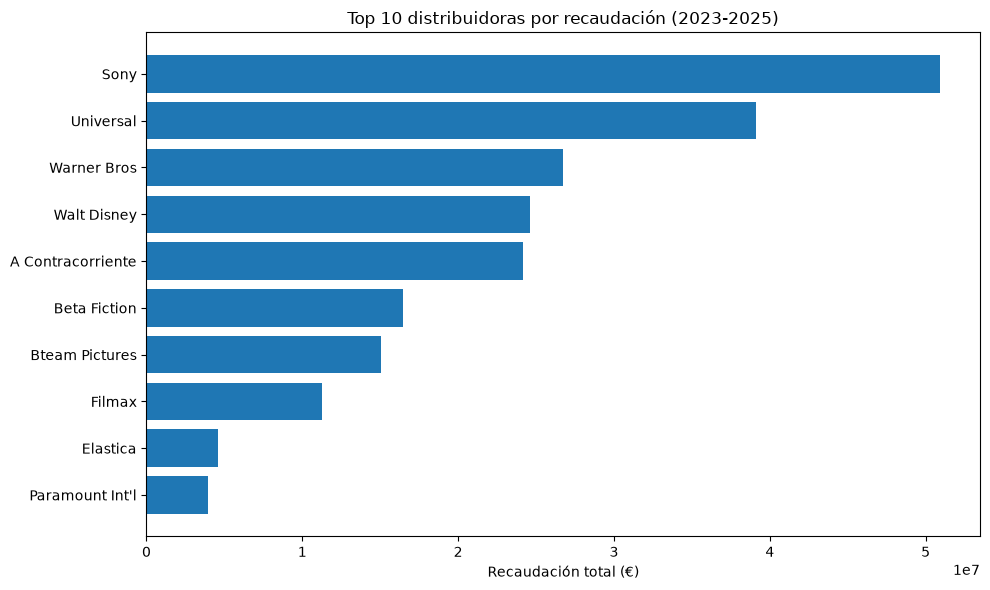

In [4]:
top10 = recaudacion_por_distribuidora.head(10)
plt.figure(figsize=(10, 6))
plt.barh(top10.index[::-1], top10.values[::-1])
plt.xlabel("Recaudación total (€)")
plt.title("Top 10 distribuidoras por recaudación (2023-2025)")
plt.tight_layout(); plt.show()

Bloque 5 — Resumen anual (recaudación, espectadores, número de películas)

      recaudacion  espectadores  num_peliculas
anio                                          
2023     81528424      13197207            568
2024     82270234      12986185            558
2025     79351850      12313318            727


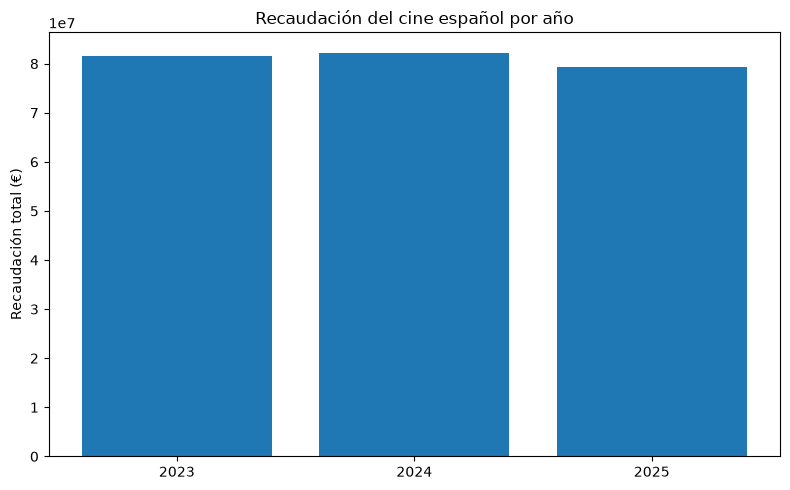

In [5]:
resumen_anual = df_final.groupby("anio")[["recaudacion", "espectadores"]].sum()
resumen_anual["num_peliculas"] = df_final.groupby("anio").size()
print(resumen_anual)

plt.figure(figsize=(8, 5))
plt.bar(resumen_anual.index.astype(str), resumen_anual["recaudacion"])
plt.ylabel("Recaudación total (€)")
plt.title("Recaudación del cine español por año")
plt.tight_layout(); plt.show()

Bloque 6 — Top 10 películas por recaudación (última celda de este notebook)

In [6]:
top10_peliculas = df_final.sort_values("recaudacion", ascending=False).head(10)
top10_peliculas[["titulo", "distribuidora", "anio", "recaudacion", "espectadores"]]

,titulo,distribuidora,anio,recaudacion,espectadores
568,Padre no hay mas que uno 4,Sony,2024,13442979,2179045
1126,Padre no hay mas que uno 5,Sony,2025,13406008,2043434
0,Campeonex,Universal,2023,11888158,1975785
1,Ocho Apellidos Marroquis,Universal,2023,9791499,1439146
569,"Infiltrada, La",Beta Fiction,2024,8108000,1274000
2,Vacaciones de verano,Sony,2023,7417977,1245648
3,Momias,Warner Bros,2023,5915965,960628
1127,"Cautivo, El",Walt Disney,2025,5284665,792007
570,Buffalo Kids,Warner Bros,2024,5226939,837070
571,Odio el verano,Sony,2024,5211627,818250
